naive: grid done
b1: grid done
b2: grid done


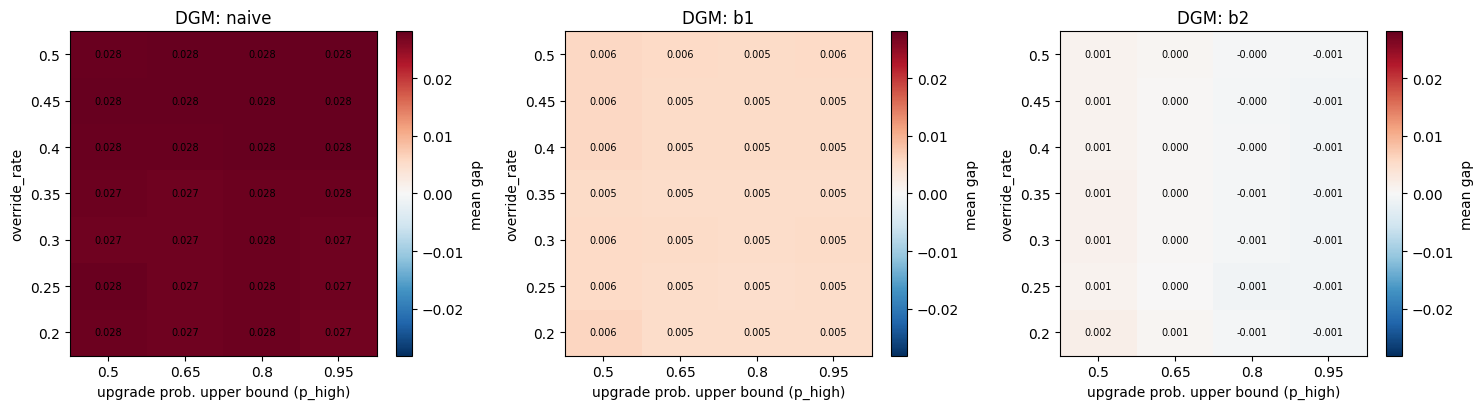

Figure saved: 04d_sensitivity_heatmaps.png

Interpretation: if the naive panel is uniformly positive while the
b1/b2 panels are near zero across the whole grid, the upgrade-risk
effect is confirmed to be an artifact of pd_system circularity,
robust to the choice of override_rate and probability spread.


In [1]:
# NB04d_override_simulation_sensitivity.ipynb

# %% [markdown]
# # NB04d – Parameter Sensitivity Analysis
# **Purpose:** Show that the central conclusion — the upgrade-risk gap is
# present under the naive DGM but collapses under the pd-independent DGMs —
# is not an artifact of the specific override_rate or upgrade-probability
# spread chosen. We sweep both parameters on a grid and record the gap for
# each DGM at every grid point. Addresses the reviewer request for parameter
# sensitivity analysis.
#
# **Swept parameters:**
#   override_rate : {0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50}
#   prob_spread   : upper bound of upgrade probability (p_high), controlling
#                   how strongly upgrades concentrate. {0.50, 0.65, 0.80, 0.95}.
#                   For 'naive', p_high rescales GRADE_UPGRADE_PROB proportionally.
#
# Each cell = mean gap over N_REP_GRID seeds (kept small for runtime).
#
# **Input:**  `data/processed/graded_data.parquet`
# **Output:**
#   - `results/tables/04d_sensitivity_grid.csv`
#   - `results/figures/04d_sensitivity_heatmaps.png`

# %%
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

graded = pd.read_parquet(PROC_DIR + "graded_data.parquet")

GRADE_LABELS = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]
GRADE_ORDER  = {g: i for i, g in enumerate(GRADE_LABELS)}
GRADE_UPGRADE_PROB = {
    "AAA": 0.10, "AA": 0.15, "A": 0.20, "BBB": 0.35,
    "BB": 0.50, "B": 0.70, "CCC": 0.80,
}
# Baseline max of the naive schedule, used to rescale under prob_spread
_NAIVE_MAX = max(GRADE_UPGRADE_PROB.values())   # 0.80

# %% [markdown]
# ## 1. Engine with tunable probability spread

# %%
def _upgrade_prob_naive(df, p_high):
    """Rescale the grade schedule so its max equals p_high."""
    scale = p_high / _NAIVE_MAX
    sched = {g: min(p * scale, 1.0) for g, p in GRADE_UPGRADE_PROB.items()}
    return df["system_grade"].map(sched).values

def _upgrade_prob_from_driver(df, driver_col, p_low, p_high):
    x = df[driver_col].astype(float)
    r = x.rank(pct=True, na_option="keep").values
    r = np.where(np.isnan(r), 0.5, r)
    return p_low + (p_high - p_low) * r

def gap_for(df, dgm, driver_col, override_rate, p_high, seed):
    rng = np.random.default_rng(seed)
    n = len(df)
    if dgm == "naive":
        upgrade_prob = _upgrade_prob_naive(df, p_high)
    else:
        upgrade_prob = _upgrade_prob_from_driver(df, driver_col, 0.10, p_high)
    override_mask = rng.random(n) < override_rate
    upgrade_flag  = rng.random(n) < upgrade_prob
    notch         = np.where(rng.random(n) < 0.70, 1, 2)
    delta = np.where(upgrade_flag, -notch, notch)
    new_ord = df["grade_ordinal"].values.copy().astype(int)
    new_ord[override_mask] = (new_ord[override_mask]
                              + delta[override_mask]).clip(0, 6)
    applied = new_ord - df["grade_ordinal"].values
    d = pd.DataFrame({"default": df["default"].values, "applied": applied,
                      "ov": override_mask})
    dr_up   = d.loc[d.ov & (d.applied < 0), "default"].mean()
    dr_none = d.loc[~d.ov, "default"].mean()
    return dr_up - dr_none

# %% [markdown]
# ## 2. Sweep the grid

# %%
OVERRIDE_RATES = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
PROB_SPREADS   = [0.50, 0.65, 0.80, 0.95]
N_REP_GRID     = 30
DGM_DRIVER     = {"naive": None, "b1": "Attr43", "b2": "Attr29"}

records = []
for name, driver in DGM_DRIVER.items():
    for orr in OVERRIDE_RATES:
        for ph in PROB_SPREADS:
            gaps = [gap_for(graded, name, driver, orr, ph, seed=5000 + s)
                    for s in range(N_REP_GRID)]
            records.append({"dgm": name, "override_rate": orr,
                            "p_high": ph, "mean_gap": np.nanmean(gaps)})
    print(f"{name}: grid done")

grid = pd.DataFrame(records)
grid.to_csv(TABLE_DIR + "04d_sensitivity_grid.csv", index=False)

# %% [markdown]
# ## 3. Heatmaps: mean gap across the grid, one panel per DGM
# A near-zero, flat surface for b1/b2 vs a strongly positive surface for
# naive is the visual evidence that the effect is design-induced.

# %%
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
vmax = grid["mean_gap"].abs().max()

for ax, name in zip(axes, ["naive", "b1", "b2"]):
    piv = (grid[grid.dgm == name]
           .pivot(index="override_rate", columns="p_high", values="mean_gap"))
    im = ax.imshow(piv.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   aspect="auto", origin="lower")
    ax.set_xticks(range(len(PROB_SPREADS)))
    ax.set_xticklabels(PROB_SPREADS)
    ax.set_yticks(range(len(OVERRIDE_RATES)))
    ax.set_yticklabels(OVERRIDE_RATES)
    ax.set_xlabel("upgrade prob. upper bound (p_high)")
    ax.set_ylabel("override_rate")
    ax.set_title(f"DGM: {name}")
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f"{piv.values[i, j]:.3f}",
                    ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, label="mean gap")

plt.tight_layout()
plt.savefig(FIG_DIR + "04d_sensitivity_heatmaps.png", bbox_inches="tight")
plt.show()
print("Figure saved: 04d_sensitivity_heatmaps.png")
print("\nInterpretation: if the naive panel is uniformly positive while the")
print("b1/b2 panels are near zero across the whole grid, the upgrade-risk")
print("effect is confirmed to be an artifact of pd_system circularity,")
print("robust to the choice of override_rate and probability spread.")

In [2]:
# NB04d_sensitivity_check.ipynb  (append to NB04d)

# %% [markdown]
# ## 4. Numeric confirmation of grid ranges
# Print the min/max/mean of mean_gap per DGM so the paper can cite the
# actual spread rather than relying on the heatmap alone.

# %%
rng_tbl = (grid.groupby("dgm")["mean_gap"]
                .agg(min_gap="min", max_gap="max",
                     mean_gap="mean", abs_max="max")
                .round(4)
                .reindex(["naive", "b1", "b2"]))
# abs_max should be the largest magnitude, recompute properly
rng_tbl["abs_max"] = (grid.groupby("dgm")["mean_gap"]
                          .apply(lambda s: s.abs().max())
                          .round(4).reindex(["naive", "b1", "b2"]))

print("=== mean_gap range across the full parameter grid, per DGM ===")
print(rng_tbl.to_string())

# Also: does any b1/b2 cell ever reach the naive floor?
naive_min = grid.loc[grid.dgm == "naive", "mean_gap"].min()
b_max     = grid.loc[grid.dgm.isin(["b1", "b2"]), "mean_gap"].max()
print(f"\nnaive minimum gap across grid : {naive_min:.4f}")
print(f"b1/b2 maximum gap across grid : {b_max:.4f}")
print(f"Separation (naive_min - b_max): {naive_min - b_max:.4f}")
print("Positive separation => naive and pd-independent DGMs never overlap,")
print("i.e. the effect is design-induced across the entire grid.")

=== mean_gap range across the full parameter grid, per DGM ===
       min_gap  max_gap  mean_gap  abs_max
dgm                                       
naive   0.0272   0.0281    0.0277   0.0281
b1      0.0050   0.0059    0.0054   0.0059
b2     -0.0009   0.0017    0.0001   0.0017

naive minimum gap across grid : 0.0272
b1/b2 maximum gap across grid : 0.0059
Separation (naive_min - b_max): 0.0213
Positive separation => naive and pd-independent DGMs never overlap,
i.e. the effect is design-induced across the entire grid.
